In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


import dask
import dask.dataframe as dd
from dask.distributed import Client
from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

### Load Augmented DF

In [2]:
augmented_df = dd.read_csv("../../data/augmented_us-counties_latest.csv", assume_missing=True).compute()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])
augmented_df["shifted_log_rolled_cases"] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-7)

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
# Check for gaps
gt_columns = ["fips", "days_from_start", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


### Load TLGRF Benchmark Dataset

In [4]:
benchmark_TLGRF_dataset = dd.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", assume_missing=True).compute()
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])

df = benchmark_TLGRF_dataset.copy()
fips_list = df["fips"].unique()
display(benchmark_TLGRF_dataset)

,fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
0,1001.0,69.0,NaN,NaN,Autauga,Alabama,2020-03-30,5.142857,1.831438,2.469309,NaN
1,1001.0,70.0,NaN,NaN,Autauga,Alabama,2020-03-31,6.000000,1.960095,2.528012,NaN
2,1001.0,71.0,NaN,NaN,Autauga,Alabama,2020-04-01,6.857143,2.074070,2.550561,NaN
3,1001.0,72.0,NaN,NaN,Autauga,Alabama,2020-04-02,7.428571,2.143422,2.625703,NaN
4,1001.0,73.0,NaN,NaN,Autauga,Alabama,2020-04-03,8.285714,2.239189,2.676117,NaN
...,...,...,...,...,...,...,...,...,...,...,...
10201,99999.0,1153.0,1456.032249,-0.030986,New York City,New York,2023-03-19,13972.285714,9.544910,NaN,9.328005
10202,99999.0,1154.0,1389.214236,-0.039535,New York City,New York,2023-03-20,13317.571429,9.496922,NaN,9.220178
10203,99999.0,1155.0,1323.021840,-0.054503,New York City,New York,2023-03-21,12458.714286,9.430264,NaN,9.048744
10204,99999.0,1156.0,1531.624962,-0.024711,New York City,New York,2023-03-22,12154.857143,9.405575,NaN,9.232600


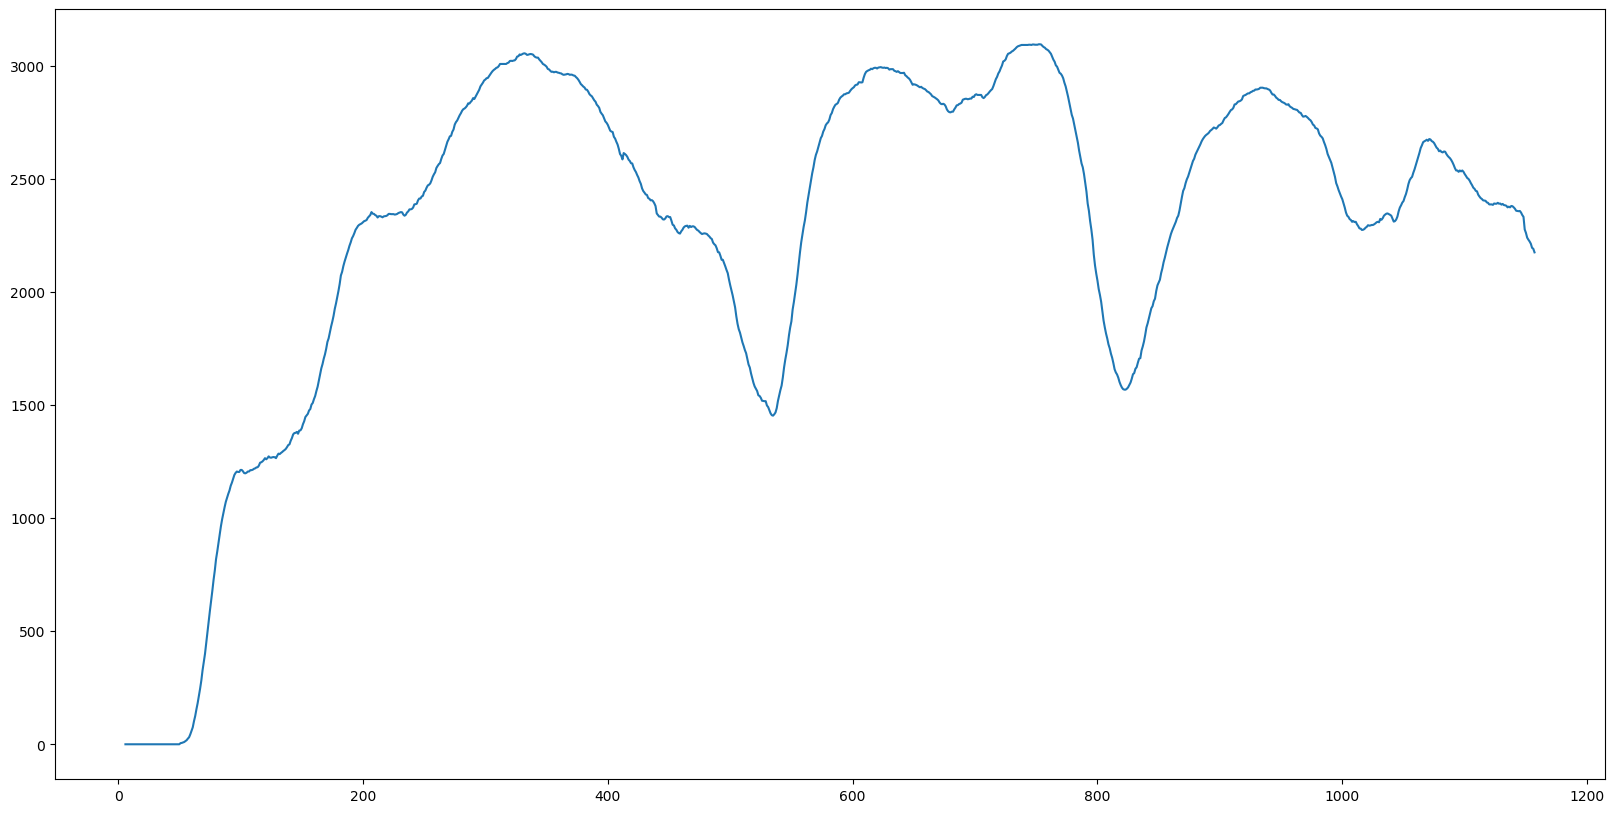

In [5]:
plt.figure(figsize=(20,10))
plt.plot(benchmark_TLGRF_dataset.groupby("days_from_start")["TLGRF_predicted_log_rolled_cases"].count())
plt.show()

### Define `read_csv_file` helper

In [6]:
def read_csv_file(file_path):
    # Read the CSV file into a pandas DataFrame
    try:
        GRF_df = pd.read_csv(file_path)
        return GRF_df
    except pd.errors.EmptyDataError:
        print(file_path)

### Read Time Variant GRF

In [7]:
directory = "./time_variant_grf_results/time_variant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_variant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_variant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_variant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_variant_file_paths)
    pbar.update(len(time_variant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [8]:
time_variant_GRF_results = pd.concat(time_variant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_variant_GRF_results["date"] = pd.to_datetime(time_variant_GRF_results["date"])
time_variant_GRF_results = time_variant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_variant_GRF_results = time_variant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
time_variant_GRF_results = pd.merge(time_variant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(time_variant_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,0.014734,3.165860,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,-0.010749,3.007321,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,-0.008377,3.023923,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,0.003237,3.118235,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,0.018454,3.243964,3.256447
...,...,...,...,...,...,...,...,...,...,...
2424868,99999,2022-12-18,New York City,New York,1062,78943.714286,11.276504,-0.000358,11.274001,11.343370
2424869,99999,2022-12-19,New York City,New York,1063,81291.571429,11.305811,-0.000356,11.303319,11.317096
2424870,99999,2022-12-20,New York City,New York,1064,82945.142857,11.325948,-0.000614,11.321650,11.308855
2424871,99999,2022-12-22,New York City,New York,1066,85309.714286,11.354057,-0.000325,11.351785,11.290187


In [9]:
time_varying_counts = time_variant_GRF_results.groupby("date")["GRF_predicted_log_rolled_cases"].count()
display(time_varying_counts.sort_values())
time_variant_GRF_results[time_variant_GRF_results["date"]=="2021-08-07"]

date
2020-03-09       3
2020-03-10       4
2020-03-11       5
2020-03-12       6
2020-03-13       8
              ... 
2022-02-07    3095
2022-02-12    3096
2022-02-06    3096
2022-02-11    3096
2022-02-10    3097
Name: GRF_predicted_log_rolled_cases, Length: 1019, dtype: int64

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
478,1001,2021-08-07,Autauga,Alabama,564,329.571429,5.801125,-0.000400,5.798323,6.185532
1471,1003,2021-08-07,Baldwin,Alabama,564,3789.000000,8.240148,-0.000309,8.237988,8.503404
2416,1005,2021-08-07,Barbour,Alabama,564,180.857143,5.203771,-0.000312,5.201590,5.600906
3343,1007,2021-08-07,Bibb,Alabama,564,235.571429,5.466673,-0.000352,5.464207,5.722043
4257,1009,2021-08-07,Blount,Alabama,564,421.000000,6.045242,-0.000352,6.042776,6.306718
...,...,...,...,...,...,...,...,...,...,...
2419895,56041,2021-08-07,Uinta,Wyoming,564,130.571429,4.880310,-0.000245,4.878594,5.285160
2420975,56045,2021-08-07,Weston,Wyoming,564,25.142857,3.267394,-0.000290,3.265361,3.520883
2422217,78010,2021-08-07,St. Croix,Virgin Islands,564,235.000000,5.464255,-0.000075,5.463731,5.710758
2423361,78030,2021-08-07,St. Thomas,Virgin Islands,564,425.428571,6.055679,-0.001712,6.043698,6.329390


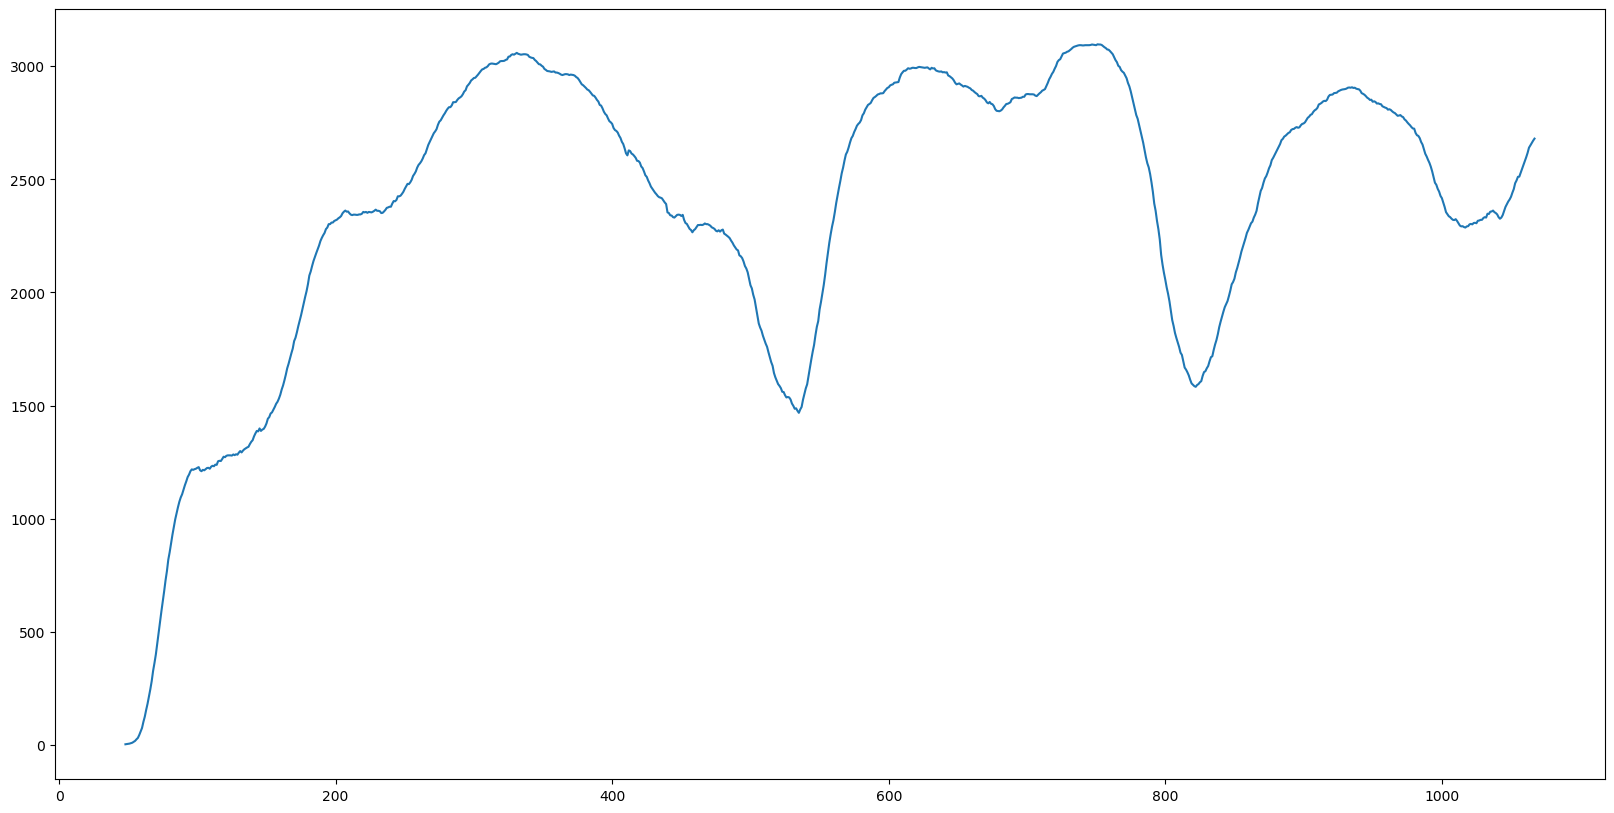

In [10]:
plt.figure(figsize=(20,10))
plt.plot(time_variant_GRF_results.groupby("days_from_start")["GRF_predicted_log_rolled_cases"].count())
plt.show()

In [11]:
directory = "./shifted_W_time_variant_grf_results/time_variant_grf_backtest_state_forests_windowsize=2_numtrees=100"
shifted_W_time_variant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(shifted_W_time_variant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    shifted_W_time_variant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in shifted_W_time_variant_file_paths)
    pbar.update(len(shifted_W_time_variant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [12]:
shifted_W_time_variant_GRF_results = pd.concat(shifted_W_time_variant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
shifted_W_time_variant_GRF_results["date"] = pd.to_datetime(shifted_W_time_variant_GRF_results["date"])
shifted_W_time_variant_GRF_results = shifted_W_time_variant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
shifted_W_time_variant_GRF_results = shifted_W_time_variant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
shifted_W_time_variant_GRF_results = pd.merge(shifted_W_time_variant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(shifted_W_time_variant_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,0,0.029451,3.268881,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,1,0.033634,3.318004,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,2,0.028902,3.284877,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,3,0.025175,3.271800,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,4,0.023614,3.280084,3.256447
...,...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,13972.285714,9.544910,1103,-0.009829,9.476110,NaN
2649554,99999,2023-03-20,New York City,New York,1154,13317.571429,9.496922,1104,-0.004860,9.462904,NaN
2649555,99999,2023-03-21,New York City,New York,1155,12458.714286,9.430264,1105,-0.002493,9.412810,NaN
2649556,99999,2023-03-22,New York City,New York,1156,12154.857143,9.405575,1106,-0.003673,9.379860,NaN


### Read Time Invariant GRF

In [13]:
directory = "./time_invariant_grf_results/time_invariant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_invariant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_invariant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_invariant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_invariant_file_paths)
    pbar.update(len(time_invariant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [14]:
time_invariant_GRF_results = pd.concat(time_invariant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_invariant_GRF_results["date"] = pd.to_datetime(time_invariant_GRF_results["date"])
time_invariant_GRF_results = time_invariant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_invariant_GRF_results = time_invariant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])

time_invariant_GRF_results = pd.merge(time_invariant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(time_invariant_GRF_results)

,fips,date,county,state,days_from_start,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,3.062723,0.075195,3.589089,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,3.082565,0.064403,3.533383,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,3.082565,0.053266,3.455429,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,3.095578,0.056698,3.492464,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,3.114784,0.055530,3.503493,3.256447
...,...,...,...,...,...,...,...,...,...
2454871,99999,2023-03-19,New York City,New York,1153,9.544910,0.001367,9.554478,NaN
2454872,99999,2023-03-20,New York City,New York,1154,9.496922,0.001389,9.506648,NaN
2454873,99999,2023-03-21,New York City,New York,1155,9.430264,0.001364,9.439815,NaN
2454874,99999,2023-03-22,New York City,New York,1156,9.405575,0.001365,9.415132,NaN


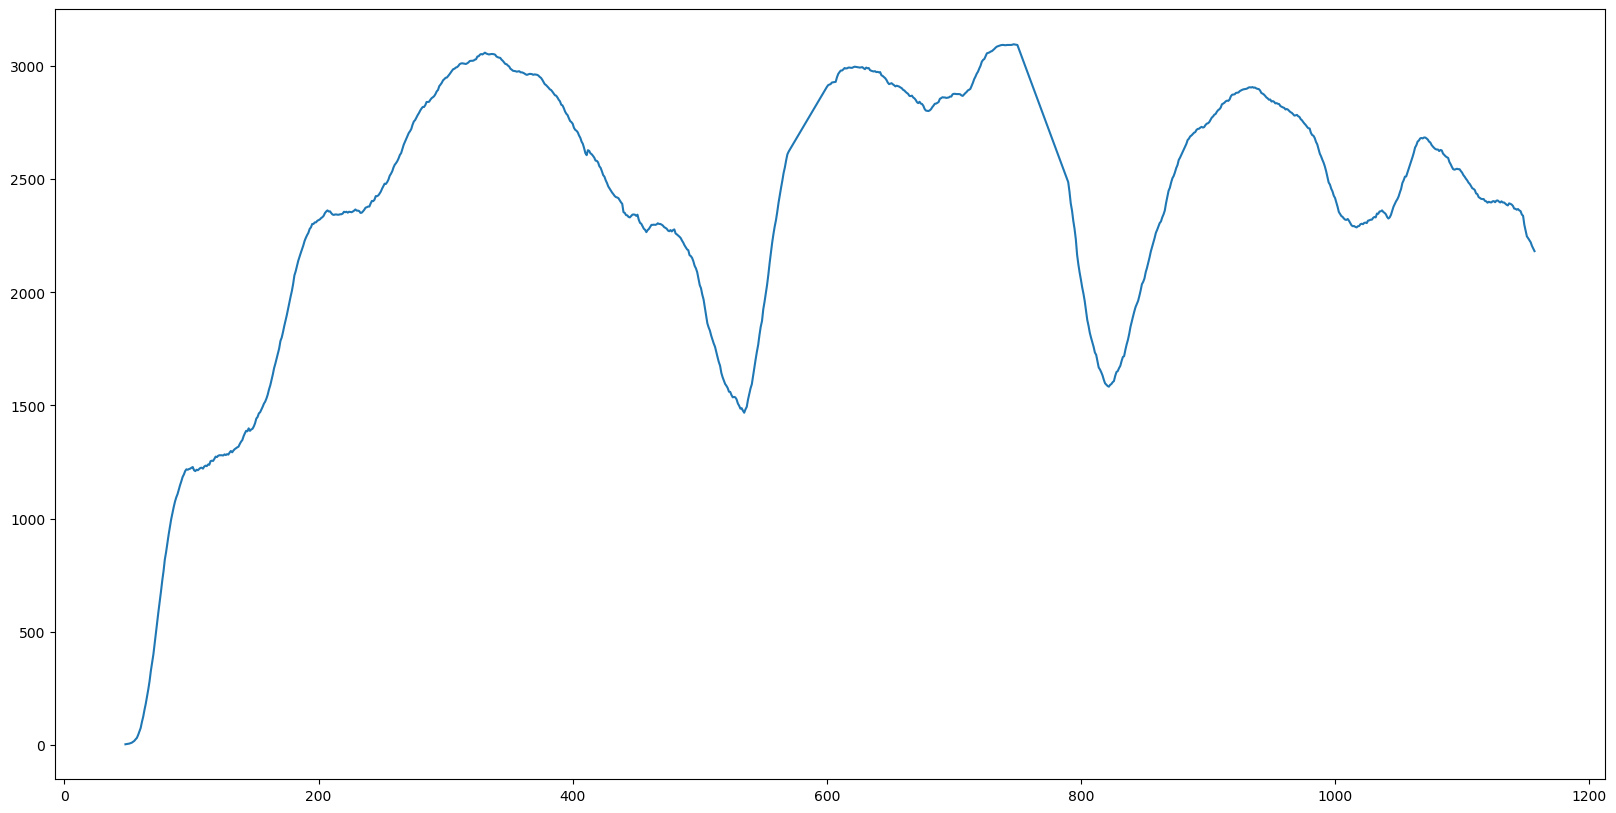

In [15]:
plt.figure(figsize=(20,10))
plt.plot(time_invariant_GRF_results.groupby("days_from_start")["GRF_predicted_log_rolled_cases"].count())
plt.show()

In [16]:
directory = "./shifted_W_time_invariant_grf_results/time_invariant_grf_backtest_state_forests_windowsize=2_numtrees=100"
shifted_W_time_invariant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(shifted_W_time_invariant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    shifted_W_time_invariant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in shifted_W_time_invariant_file_paths)
    pbar.update(len(shifted_W_time_invariant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

In [17]:
shifted_W_time_invariant_GRF_results = pd.concat(shifted_W_time_invariant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
shifted_W_time_invariant_GRF_results["date"] = pd.to_datetime(shifted_W_time_invariant_GRF_results["date"])
shifted_W_time_invariant_GRF_results = shifted_W_time_invariant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
shifted_W_time_invariant_GRF_results = shifted_W_time_invariant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])

shifted_W_time_invariant_GRF_results = pd.merge(shifted_W_time_invariant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
display(shifted_W_time_invariant_GRF_results)

,fips,date,county,state,days_from_start,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,3.062723,0,0.088425,3.681699,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,3.082565,1,0.081830,3.655375,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,3.082565,2,0.083574,3.667585,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,3.095578,3,0.075670,3.625265,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,3.114784,4,0.069887,3.603995,3.256447
...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,9.544910,1103,0.001397,9.554692,NaN
2649554,99999,2023-03-20,New York City,New York,1154,9.496922,1104,0.001370,9.506510,NaN
2649555,99999,2023-03-21,New York City,New York,1155,9.430264,1105,0.001407,9.440112,NaN
2649556,99999,2023-03-22,New York City,New York,1156,9.405575,1106,0.001395,9.415341,NaN


### Compute RMSE and MAE

In [18]:
rmse_GRF_func = lambda x: np.sqrt(np.nanmean((x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_GRF_func = lambda x: np.nanmean(np.abs(x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
#

log_20 = np.log(20 + 1.1)

TLGRF_df = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= log_20]
TLGRF_df = TLGRF_df[TLGRF_df["date"] <= "2022-12-31"]


time_invariant_GRF_df = time_invariant_GRF_results[time_invariant_GRF_results["log_rolled_cases"] >= log_20]
time_invariant_GRF_df = time_invariant_GRF_df[time_invariant_GRF_df["date"] <= "2022-12-31"]

time_variant_GRF_df = time_variant_GRF_results[time_variant_GRF_results["log_rolled_cases"] >= log_20]
time_variant_GRF_df = time_variant_GRF_df[time_variant_GRF_df["date"] <= "2022-12-31"]

shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_results[shifted_W_time_invariant_GRF_results["log_rolled_cases"] >= log_20]
shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df[shifted_W_time_invariant_GRF_df["date"] <= "2022-12-31"]

shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_results[shifted_W_time_variant_GRF_results["log_rolled_cases"] >= log_20]
shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df[shifted_W_time_variant_GRF_df["date"] <= "2022-12-31"]



#TLGRF
RMSE_TLGRF = TLGRF_df.groupby("date").apply(rmse_TLGRF_func)
MAE_TLGRF = TLGRF_df.groupby("date").apply(mae_TLGRF_func)
#Time Invariant GRF
RMSE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(mae_GRF_func)
#Time Variant GRF
RMSE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(mae_GRF_func)

# Shifted W Time Invariant
RMSE_shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df.groupby("date").apply(mae_GRF_func)
# Shifted W Time Variant GRF
RMSE_shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df.groupby("date").apply(mae_GRF_func)



/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: Mean of empty slice
  This is separate from the ipykernel package so we can avoid doing imports until
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.


In [19]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["MAE"] = [MAE_shifted_W_time_invariant_GRF_df.median(), MAE_shifted_W_time_variant_GRF_df.median(), MAE_time_invariant_GRF_df.median(), MAE_time_variant_GRF_df.median(), MAE_TLGRF.median()]
metrics_comparison_df["RMSE"] = [RMSE_shifted_W_time_invariant_GRF_df.median(), RMSE_shifted_W_time_variant_GRF_df.median(), RMSE_time_invariant_GRF_df.median(), RMSE_time_variant_GRF_df.median(), RMSE_TLGRF.median()]
metrics_comparison_df.index = ["Time Invariant Shifted W GRF", "Time Variant Shifted W GRF", "Time Invariant GRF", "Time Variant GRF", "TLGRF"]
metrics_comparison_df

,MAE,RMSE
Time Invariant Shifted W GRF,0.218343,0.291310
Time Variant Shifted W GRF,0.203763,0.275078
Time Invariant GRF,0.215902,0.286381
Time Variant GRF,0.207021,0.278709
TLGRF,0.126516,0.194870


In [20]:
[RMSE_time_invariant_GRF_df.median(), RMSE_TLGRF.median()]

[0.2863808456437754, 0.19487029059240693]

In [21]:
[MAE_time_invariant_GRF_df.median(), MAE_TLGRF.median()]

[0.21590191695331346, 0.1265164490059572]

In [22]:
days_to_date_df = time_variant_GRF_results[["days_from_start","date"]]
days_to_date_df.drop_duplicates(inplace=True)
days_to_date_df = days_to_date_df.sort_values(by="date")

date0 = days_to_date_df["date"].min() - pd.Timedelta(days=days_to_date_df["days_from_start"].min())
date0 = date0.date()
missing_days_df = pd.DataFrame({'days_from_start': range(0, days_to_date_df["days_from_start"].max()),
                                'date': pd.date_range(start=date0, periods=days_to_date_df["days_from_start"].max())})
#date0, days_to_date_df["date"].min(), pd.Timedelta(days=days_to_date_df["days_from_start"].min())
missing_days_df

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


,days_from_start,date
0,0,2020-01-21
1,1,2020-01-22
2,2,2020-01-23
3,3,2020-01-24
4,4,2020-01-25
...,...,...
1062,1062,2022-12-18
1063,1063,2022-12-19
1064,1064,2022-12-20
1065,1065,2022-12-21


In [23]:
days_to_date_df[days_to_date_df["date"]=="2021-09-12"]

,days_from_start,date
514,600,2021-09-12


### Load Other Benchmarks

In [24]:
with open("../benchmark_tcv_kmeans_code/first_design_merged_df_dict.pickle", 'rb') as file:
    first_design_merged_df_dict = pickle.load(file)
with open("../benchmark_tcv_kmeans_code/second_design_merged_df_dict.pickle", 'rb') as file:
    second_design_merged_df_dict = pickle.load(file)


In [25]:
ctcv_df = second_design_merged_df_dict[3136]
tcv_df = second_design_merged_df_dict[1]
ctcv_df = pd.merge(ctcv_df, days_to_date_df, on="days_from_start", how="left")
tcv_df = pd.merge(tcv_df, days_to_date_df, on="days_from_start", how="left")
ctcv_df

,days_from_start,total_mse,total_mae,nsamples_mse,nsamples_mae,rmse,mae,date
0,20.0,0.559616,0.313170,1.0,1.0,0.748075,0.313170,NaT
1,21.0,0.693147,0.480453,1.0,1.0,0.832555,0.480453,NaT
2,22.0,0.372013,0.138393,1.0,1.0,0.609928,0.138393,NaT
3,23.0,0.722027,0.261866,2.0,2.0,0.600844,0.130933,NaT
4,24.0,1.338507,0.632752,3.0,3.0,0.667959,0.210917,NaT
...,...,...,...,...,...,...,...,...
1124,1144.0,934.131399,1927.583972,3136.0,3136.0,0.545778,0.614663,NaT
1125,1145.0,969.227173,2169.818787,3136.0,3136.0,0.555936,0.691907,NaT
1126,1146.0,1076.336616,2492.645367,3136.0,3136.0,0.585849,0.794849,NaT
1127,1147.0,1190.343785,2615.273718,3136.0,3136.0,0.616096,0.833952,NaT


In [26]:
tcv_df

,days_from_start,total_mse,total_mae,nsamples_mse,nsamples_mae,rmse,mae,date
0,20.0,0.241162,0.058159,8.0,8.0,0.173624,0.007270,NaT
1,21.0,0.336472,0.113214,9.0,9.0,0.193354,0.012579,NaT
2,22.0,0.441833,0.195216,9.0,9.0,0.221568,0.021691,NaT
3,23.0,0.559616,0.313170,9.0,9.0,0.249358,0.034797,NaT
4,24.0,0.693147,0.480453,9.0,9.0,0.277518,0.053384,NaT
...,...,...,...,...,...,...,...,...
1042,1062.0,662.085962,512.866665,3136.0,3136.0,0.459483,0.163542,2022-12-18
1043,1063.0,712.640695,587.808026,3136.0,3136.0,0.476702,0.187439,2022-12-19
1044,1064.0,790.143238,629.956877,3136.0,3136.0,0.501955,0.200879,2022-12-20
1045,1065.0,805.520276,543.439982,3136.0,3136.0,0.506816,0.173291,NaT


In [27]:
tcv_df["days_from_start"].value_counts().sort_values()

20.0      1
51.0      1
22.0      1
23.0      1
24.0      1
         ..
1061.0    1
1062.0    1
1063.0    1
1065.0    1
1066.0    1
Name: days_from_start, Length: 1047, dtype: int64

In [28]:
tcv_performance_df = tcv_df[["date","rmse","mae"]]
tcv_performance_df = tcv_performance_df.sort_values(by="date")
tcv_performance_df = tcv_performance_df[tcv_performance_df["date"].isin(MAE_time_variant_GRF_df.index)]
tcv_performance_df.set_index("date", inplace=True)


ctcv_performance_df = ctcv_df[["date","rmse","mae"]]
ctcv_performance_df = ctcv_performance_df.sort_values(by="date")
ctcv_performance_df = ctcv_performance_df[ctcv_performance_df["date"].isin(MAE_time_variant_GRF_df.index)]
ctcv_performance_df.set_index("date", inplace=True)

In [29]:
metrics_comparison_df

,MAE,RMSE
Time Invariant Shifted W GRF,0.218343,0.291310
Time Variant Shifted W GRF,0.203763,0.275078
Time Invariant GRF,0.215902,0.286381
Time Variant GRF,0.207021,0.278709
TLGRF,0.126516,0.194870


In [30]:
latex_table = metrics_comparison_df.to_latex(column_format='c'*len(metrics_comparison_df.columns), float_format='%.3f', escape=False)
print(latex_table)

\begin{tabular}{cc}
\toprule
{} &   MAE &  RMSE \\
\midrule
Time Invariant Shifted W GRF & 0.218 & 0.291 \\
Time Variant Shifted W GRF   & 0.204 & 0.275 \\
Time Invariant GRF           & 0.216 & 0.286 \\
Time Variant GRF             & 0.207 & 0.279 \\
TLGRF                        & 0.127 & 0.195 \\
\bottomrule
\end{tabular}



In [31]:
ctcv_performance_df["rmse"].median(), ctcv_performance_df["mae"].median() 

(0.4358556757203166, 0.14651071221347012)

In [32]:
tcv_performance_df["rmse"].median(), tcv_performance_df["mae"].median()

(0.5185104382973871, 0.20062617444100345)

### Plot TLGRF vs GRF

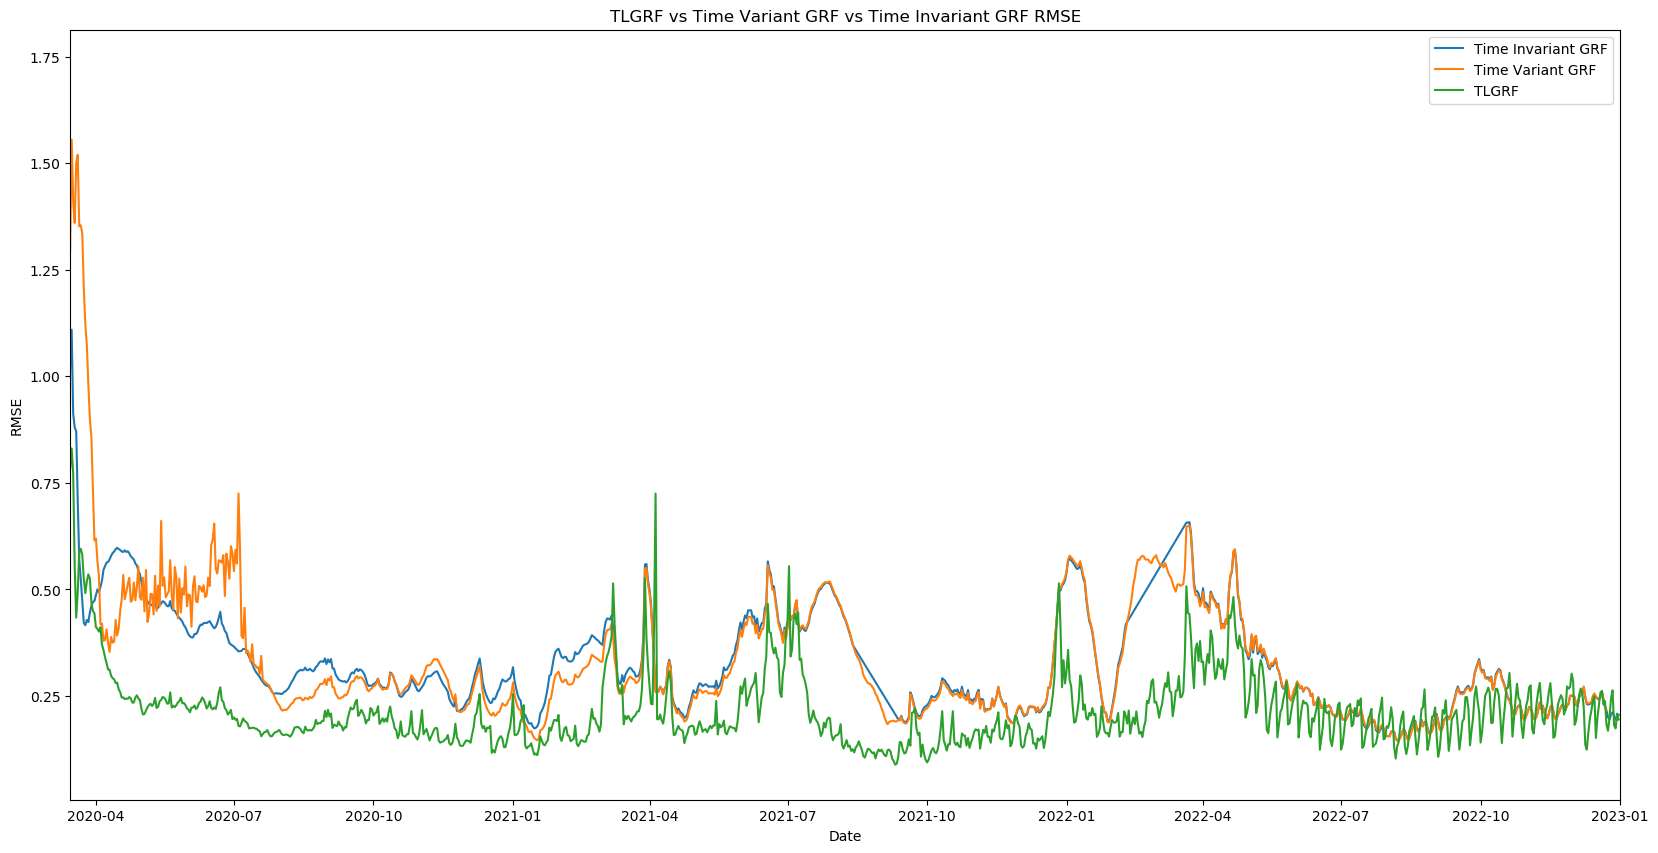

In [33]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["rmse"], label="tcv")
#plt.plot(ctcv_performance_df["rmse"], label="ctcv")
#plt.plot(RMSE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(RMSE_time_invariant_GRF_df, label="Time Invariant GRF")
plt.plot(RMSE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(RMSE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("TLGRF vs Time Variant GRF vs Time Invariant GRF RMSE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
#plt.ylim(0,0.6)
plt.savefig("updated_grf_tlgrf_rmse.png")
plt.show()


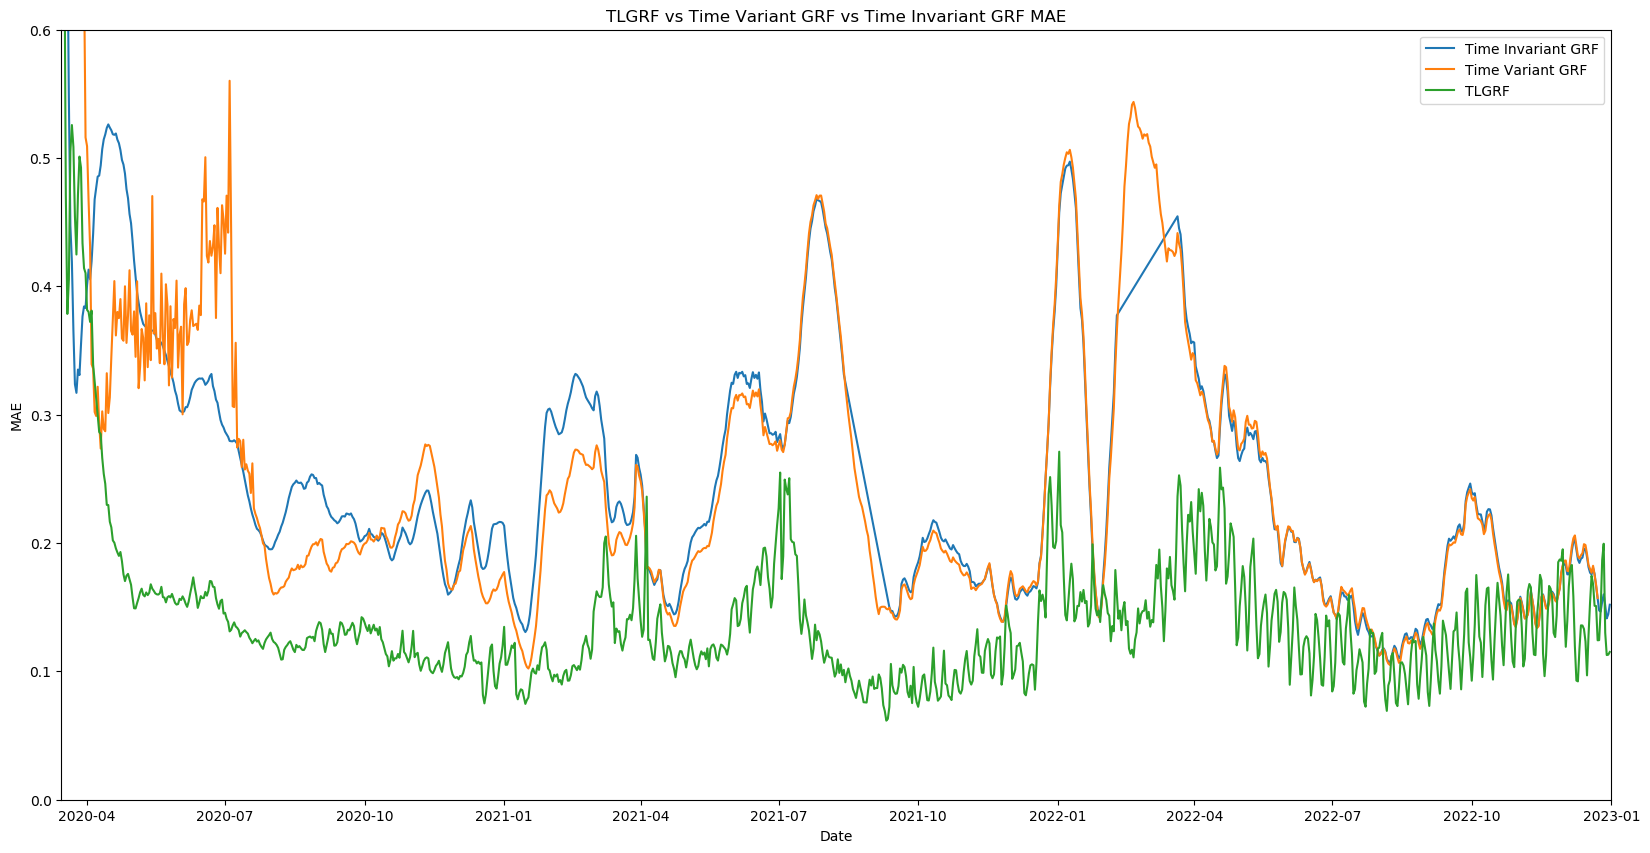

In [34]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_time_invariant_GRF_df, label="Time Invariant GRF")
plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("TLGRF vs Time Variant GRF vs Time Invariant GRF MAE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("updated_grf_tlgrf_mae.png")

plt.show()

### Comparisons between Shifted and Unshifted

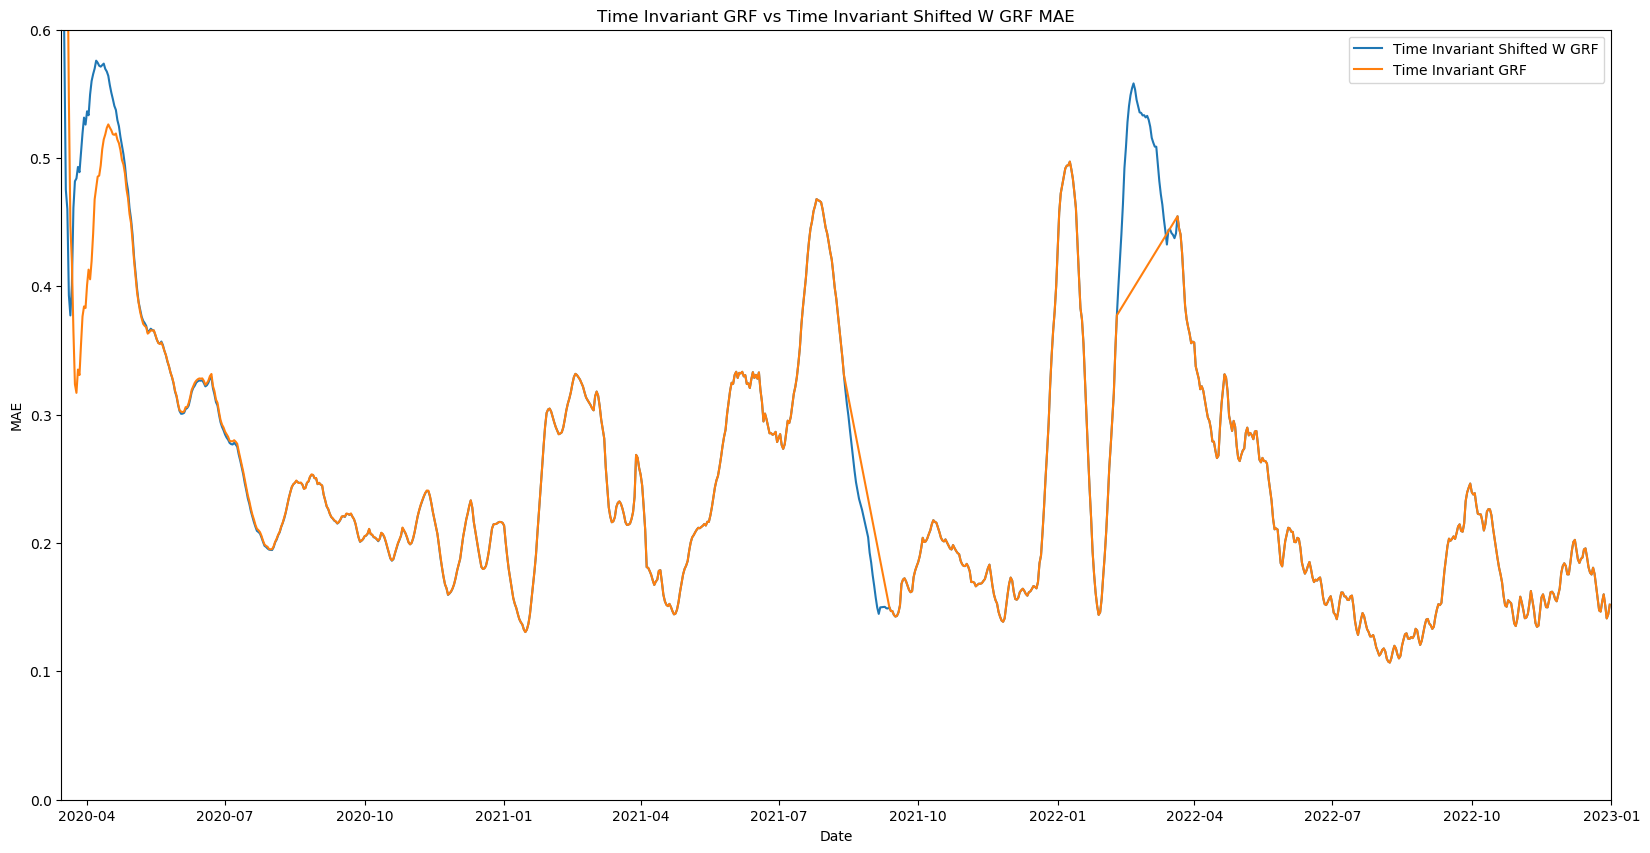

In [35]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_time_invariant_GRF_df, label="Time Invariant GRF")
#plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
#plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Time Invariant GRF vs Time Invariant Shifted W GRF MAE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
#plt.savefig("updated_grf_tlgrf_mae.png")

plt.show()

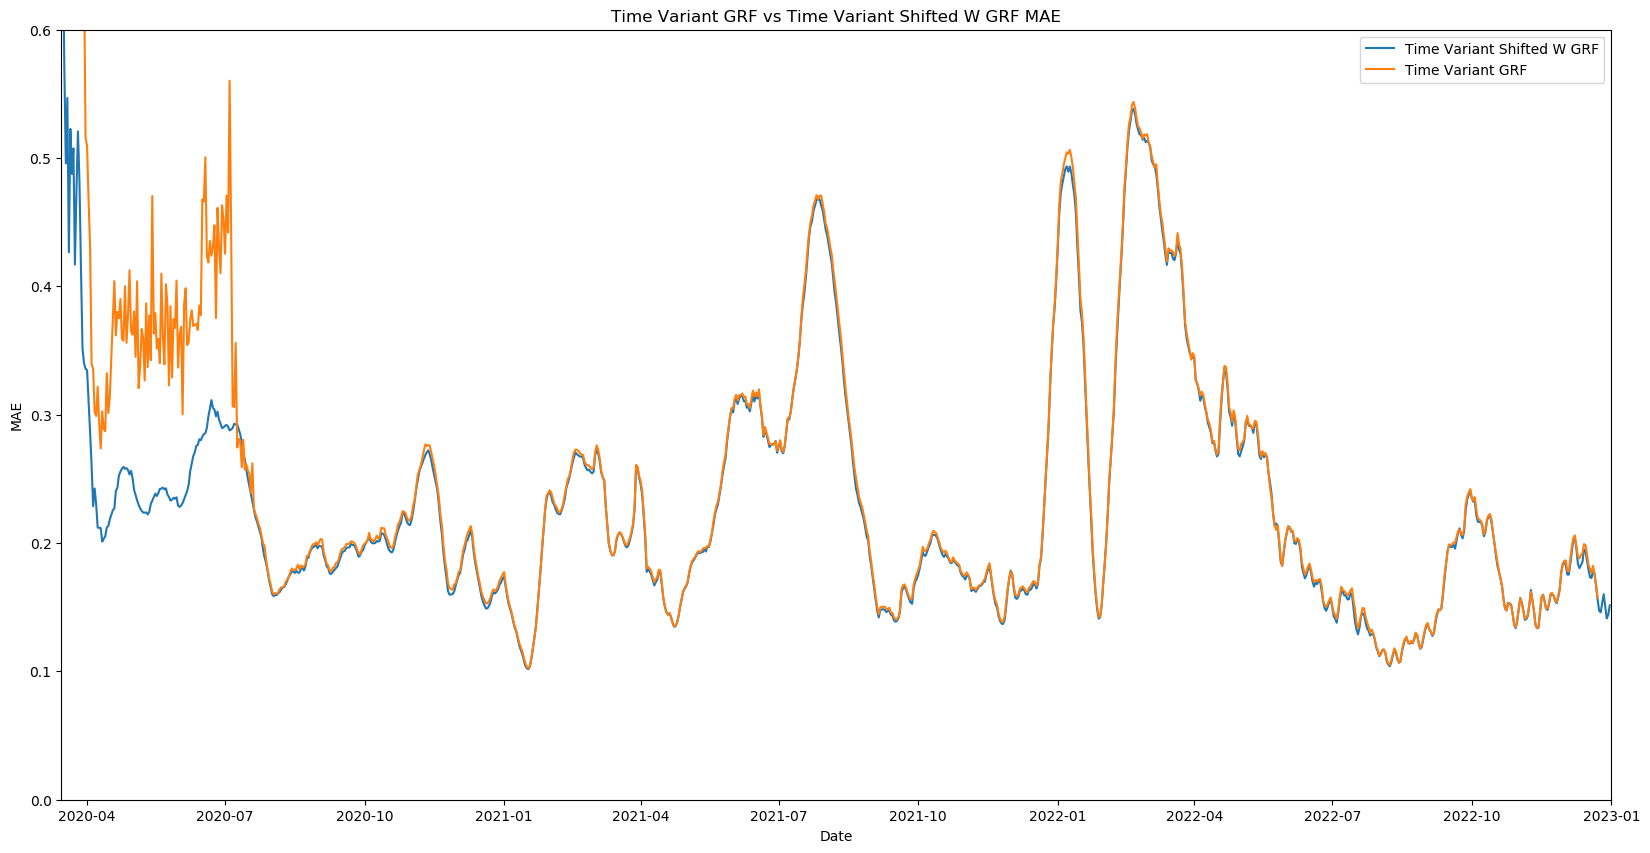

In [36]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
#plt.plot(MAE_time_invariant_GRF_df, label="Time Invariant GRF")
plt.plot(MAE_time_variant_GRF_df, label="Time Variant GRF")
#plt.plot(MAE_TLGRF, label="TLGRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Time Variant GRF vs Time Variant Shifted W GRF MAE")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
#plt.savefig("updated_grf_tlgrf_mae.png")

plt.show()

In [37]:
log_20 = np.log(20)
(TLGRF_df["log_rolled_cases"] <= log_20).sum()

0

In [38]:
RMSE_time_variant_GRF_df[~RMSE_time_variant_GRF_df.isna()].sort_values().tail(20)

date
2020-03-29    0.858644
2020-03-28    0.900558
2020-03-27    0.981243
2020-03-09    1.054362
2020-03-26    1.073671
2020-03-25    1.122078
2020-03-13    1.185453
2020-03-14    1.202101
2020-03-24    1.205979
2020-03-12    1.296002
2020-03-15    1.300894
2020-03-23    1.334695
2020-03-21    1.352157
2020-03-22    1.354433
2020-03-18    1.359791
2020-03-11    1.360335
2020-03-17    1.409455
2020-03-19    1.500324
2020-03-20    1.519832
2020-03-16    1.555185
dtype: float64

In [39]:
MAE_time_variant_GRF_df[~MAE_time_variant_GRF_df.isna()].sort_values().tail(20)

date
2020-03-29    0.766746
2020-03-28    0.824820
2020-03-27    0.909617
2020-03-14    0.948637
2020-03-13    0.950950
2020-03-26    1.010103
2020-03-09    1.026195
2020-03-15    1.038196
2020-03-25    1.048442
2020-03-12    1.088352
2020-03-24    1.136409
2020-03-11    1.157226
2020-03-18    1.217470
2020-03-17    1.221017
2020-03-21    1.253090
2020-03-23    1.260987
2020-03-22    1.279271
2020-03-19    1.339592
2020-03-16    1.348615
2020-03-20    1.409396
dtype: float64

In [40]:
time_variant_GRF_df[time_variant_GRF_df["date"] == "2022-02-20"]

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
675,1001,2022-02-20,Autauga,Alabama,761,1993.000000,7.597948,0.000034,7.598186,6.499293
1668,1003,2022-02-20,Baldwin,Alabama,761,4096.714286,8.318209,0.000068,8.318686,7.510485
2613,1005,2022-02-20,Barbour,Alabama,761,345.571429,5.848377,0.000056,5.848772,4.962545
3540,1007,2022-02-20,Bibb,Alabama,761,511.428571,6.239356,0.000023,6.239520,5.379700
4454,1009,2022-02-20,Blount,Alabama,761,1130.857143,7.031703,0.000037,7.031963,6.338266
...,...,...,...,...,...,...,...,...,...,...
2421603,69110,2022-02-20,Saipan,Northern Mariana Islands,761,1100.000000,7.004065,0.000078,7.004610,5.753796
2422414,78010,2022-02-20,St. Croix,Virgin Islands,761,414.000000,6.028519,0.000275,6.030443,5.563809
2422869,78020,2022-02-20,St. John,Virgin Islands,761,29.857143,3.432604,-0.000213,3.431113,2.646175
2423558,78030,2022-02-20,St. Thomas,Virgin Islands,761,211.000000,5.357058,-0.000030,5.356847,4.826827


In [41]:
gt_columns = ["fips", "days_from_start", "log_rolled_cases", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
benchmark_TLGRF_gt = benchmark_TLGRF_dataset[gt_columns]
time_variant_GRF_gt = time_variant_GRF_df[gt_columns]
time_invariant_GRF_gt = time_invariant_GRF_df[gt_columns]
shifted_W_time_variant_GRF_gt = shifted_W_time_variant_GRF_df[gt_columns]
shifted_W_time_invariant_GRF_gt = shifted_W_time_invariant_GRF_df[gt_columns]
check_candidates = [benchmark_TLGRF_gt, time_variant_GRF_gt, time_invariant_GRF_gt, shifted_W_time_variant_GRF_gt, shifted_W_time_invariant_GRF_gt]

In [42]:
def check_gt(df1, df2):
    #print(df1.shape)
    #print(df2.shape)
    check_df = pd.merge(df1, df2, on=["fips","days_from_start"], how="inner")
    check_x = np.sum(check_df["log_rolled_cases_x"] - check_df["log_rolled_cases_y"])
    check_y = np.sum(check_df["shifted_log_rolled_cases_x"] - check_df["shifted_log_rolled_cases_y"])
    return (check_df, check_x, check_y)

In [43]:
for i, df in enumerate(check_candidates):
    check_df, check_x, check_y = check_gt(augmented_df_gt, df)
    print(check_x, check_y)

-6.327885437862335e-11 -6.30198393469783e-11
-1.0271308248377409e-09 0.0
-9.488201335727808e-10 0.0
-1.0372858127993823e-09 0.0
-1.0372858127993823e-09 0.0


In [44]:
gt_diff = check_df["shifted_log_rolled_cases_x"] - check_df["shifted_log_rolled_cases_y"]
gt_diff = gt_diff[~gt_diff.isna()].sort_values()
gt_diff

0          0.0
1630557    0.0
1630558    0.0
1630559    0.0
1630560    0.0
          ... 
815254     0.0
815255     0.0
815256     0.0
815258     0.0
2446068    0.0
Length: 2444173, dtype: float64

In [45]:
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


In [46]:
grouped = benchmark_TLGRF_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


In [47]:
RMSE_TLGRF.to_csv("RMSE_TLGRF.csv")
MAE_TLGRF.to_csv("MAE_TLGRF.csv")
RMSE_time_invariant_GRF_df.to_csv("RMSE_time_invariant_GRF_df.csv")
MAE_time_invariant_GRF_df.to_csv("MAE_time_invariant_GRF_df.csv")
RMSE_time_variant_GRF_df.to_csv("RMSE_time_variant_GRF_df.csv")
MAE_time_variant_GRF_df.to_csv("MAE_time_variant_GRF_df.csv")

RMSE_shifted_W_time_invariant_GRF_df.to_csv("RMSE_shifted_W_time_invariant_GRF_df.csv")
MAE_shifted_W_time_invariant_GRF_df.to_csv("MAE_shifted_W_time_invariant_GRF_df.csv")
RMSE_shifted_W_time_variant_GRF_df.to_csv("RMSE_shifted_W_time_variant_GRF_df.csv")
MAE_shifted_W_time_variant_GRF_df.to_csv("MAE_shifted_W_time_variant_GRF_df.csv")
